<a href="https://colab.research.google.com/github/Kishoby/Churn_Prediction_ML/blob/Model-Evaluation/Churn_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import shutil

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

In [2]:
split_path = (
    "/content/drive/MyDrive/Project_Churn Prediction/"
    "03_Train_Test_Split"
)

model_path = (
    "/content/drive/MyDrive/Project_Churn Prediction/"
    "04_Model_Training"
)

evaluation_path = (
    "/content/drive/MyDrive/Project_Churn Prediction/"
    "05_Model_Evaluation"
)

image_path = os.path.join(
    evaluation_path,
    "Images"
)

os.makedirs(evaluation_path, exist_ok=True)
os.makedirs(image_path, exist_ok=True)

print("Model evaluation folder created successfully.")
print(evaluation_path)

Model evaluation folder created successfully.
/content/drive/MyDrive/Project_Churn Prediction/05_Model_Evaluation


In [3]:
X_test = pd.read_csv(
    f"{split_path}/X_test.csv"
)

y_test = pd.read_csv(
    f"{split_path}/y_test.csv"
).squeeze("columns")

print("Testing data loaded successfully.")

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Testing data loaded successfully.
X_test shape: (1407, 58)
y_test shape: (1407,)


In [4]:
display(X_test.head())

print("\nTarget distribution:")
display(
    y_test.value_counts()
    .sort_index()
    .to_frame("Count")
)

print(
    "\nTarget percentage:"
)

display(
    (
        y_test.value_counts(
            normalize=True
        ).sort_index() * 100
    ).round(2).to_frame("Percentage")
)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingServiceCount,TotalAdditionalServices,NoSecurityOrTechSupport,HasInternetService,FiberOpticCustomer,HighRiskBillingProfile,ChargesPerContractMonth,Tenure_MonthlyCharges_Interaction,Tenure_ServiceCount_Interaction,MonthlyCharges_ServiceCount_Interaction
0,0,59,75.95,4542.35,False,True,True,True,False,False,...,2,4,0,1,0,0,3.164583,4481.05,236,303.80
1,0,7,78.55,522.95,False,False,False,True,False,True,...,0,2,1,1,1,0,78.550000,549.85,14,157.10
2,0,54,20.10,1079.45,False,False,False,True,False,False,...,0,0,1,0,0,0,0.837500,1085.40,0,0.00
3,0,2,20.65,38.70,False,False,False,True,False,False,...,0,0,1,0,0,0,20.650000,41.30,0,0.00
4,0,71,105.15,7555.00,False,True,False,True,False,True,...,2,5,1,1,1,0,4.381250,7465.65,355,525.75



Target distribution:


,Count
Churn,
0,1033
1,374



Target percentage:


,Percentage
Churn,
0,73.42
1,26.58


In [5]:
print(
    "Missing values in X_test:",
    X_test.isnull().sum().sum()
)

print(
    "Missing values in y_test:",
    y_test.isnull().sum()
)

numeric_test = X_test.select_dtypes(
    include=[np.number]
)

print(
    "Infinite values in X_test:",
    np.isinf(numeric_test).sum().sum()
)

Missing values in X_test: 0
Missing values in y_test: 0
Infinite values in X_test: 0


In [6]:
if X_test.isnull().sum().sum() > 0:
    raise ValueError(
        "X_test contains missing values."
    )

if y_test.isnull().sum() > 0:
    raise ValueError(
        "y_test contains missing values."
    )

if np.isinf(numeric_test).sum().sum() > 0:
    raise ValueError(
        "X_test contains infinite values."
    )

if set(y_test.unique()) != {0, 1}:
    raise ValueError(
        "The target column must contain only 0 and 1."
    )

print("Testing data validation completed.")

Testing data validation completed.


In [7]:
feature_file = (
    f"{model_path}/Model_Feature_Names.csv"
)

saved_features = pd.read_csv(
    feature_file
)["Feature_Name"].tolist()

missing_features = [
    feature for feature in saved_features
    if feature not in X_test.columns
]

extra_features = [
    feature for feature in X_test.columns
    if feature not in saved_features
]

print("Missing features:", missing_features)
print("Extra features:", extra_features)

Missing features: []
Extra features: []


In [8]:
if missing_features or extra_features:
    raise ValueError(
        "The testing features do not match "
        "the model-training features."
    )

In [9]:
X_test = X_test[saved_features]

print("Feature order corrected successfully.")
print("Final X_test shape:", X_test.shape)

Feature order corrected successfully.
Final X_test shape: (1407, 58)


In [10]:
model_files = {
    "Logistic Regression":
        "Logistic_Regression_Model.pkl",

    "Decision Tree":
        "Decision_Tree_Model.pkl",

    "Random Forest":
        "Random_Forest_Model.pkl",

    "Gradient Boosting":
        "Gradient_Boosting_Model.pkl"
}

In [11]:
models = {}

for model_name, filename in model_files.items():

    full_path = os.path.join(
        model_path,
        filename
    )

    if not os.path.exists(full_path):
        raise FileNotFoundError(
            f"Model file not found: {full_path}"
        )

    models[model_name] = joblib.load(
        full_path
    )

    print(
        f"{model_name} loaded successfully."
    )

Logistic Regression loaded successfully.
Decision Tree loaded successfully.
Random Forest loaded successfully.
Gradient Boosting loaded successfully.


In [12]:
evaluation_results = []
prediction_results = pd.DataFrame({
    "Actual_Churn": y_test.reset_index(
        drop=True
    )
})

classification_reports = {}

for model_name, model in models.items():

    print("=" * 60)
    print(f"Evaluating: {model_name}")
    print("=" * 60)

    y_pred = model.predict(X_test)

    y_probability = model.predict_proba(
        X_test
    )[:, 1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_probability
    )

    average_precision = average_precision_score(
        y_test,
        y_probability
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "ROC_AUC": roc_auc,
        "Average_Precision": average_precision,
        "True_Negatives": tn,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp
    })

    prediction_column = (
        model_name.replace(" ", "_")
    )

    prediction_results[
        f"{prediction_column}_Prediction"
    ] = y_pred

    prediction_results[
        f"{prediction_column}_Probability"
    ] = y_probability

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    classification_reports[
        model_name
    ] = pd.DataFrame(report).transpose()

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "No Churn",
                "Churn"
            ],
            zero_division=0
        )
    )

Evaluating: Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

Evaluating: Decision Tree
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1033
       Churn       0.50      0.77      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407

Evaluating: Random Forest
              precision    recall  f1-score   support

    No Churn       0.86      0.83      0.84      1033
       Churn       0.57      0.62      0.59       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.72 

In [13]:
evaluation_df = pd.DataFrame(
    evaluation_results
)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC",
    "Average_Precision"
]

evaluation_df[metric_columns] = (
    evaluation_df[metric_columns]
    .round(4)
)

evaluation_df = evaluation_df.sort_values(
    by="ROC_AUC",
    ascending=False
).reset_index(drop=True)

display(evaluation_df)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Average_Precision,True_Negatives,False_Positives,False_Negatives,True_Positives
0,Gradient Boosting,0.7982,0.6442,0.5374,0.5860,0.8364,0.6483,922,111,173,201
1,Logistic Regression,0.7278,0.4925,0.7914,0.6072,0.8342,0.6355,728,305,78,296
2,Random Forest,0.7740,0.5690,0.6176,0.5923,0.8264,0.6203,858,175,143,231
3,Decision Tree,0.7349,0.5009,0.7727,0.6078,0.8147,0.5960,745,288,85,289


In [14]:
evaluation_df.to_csv(
    f"{evaluation_path}/Model_Evaluation_Results.csv",
    index=False
)

print("Model evaluation results saved.")

Model evaluation results saved.


In [15]:
prediction_results.to_csv(
    f"{evaluation_path}/All_Model_Predictions.csv",
    index=False
)

print("All model predictions saved.")

All model predictions saved.


In [16]:
for model_name, report_df in (
    classification_reports.items()
):

    safe_name = model_name.replace(
        " ",
        "_"
    )

    report_df.to_csv(
        f"{evaluation_path}/"
        f"{safe_name}_Classification_Report.csv"
    )

print("Classification reports saved.")

Classification reports saved.


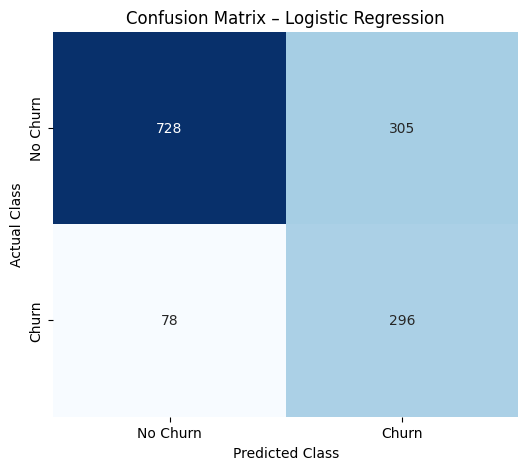

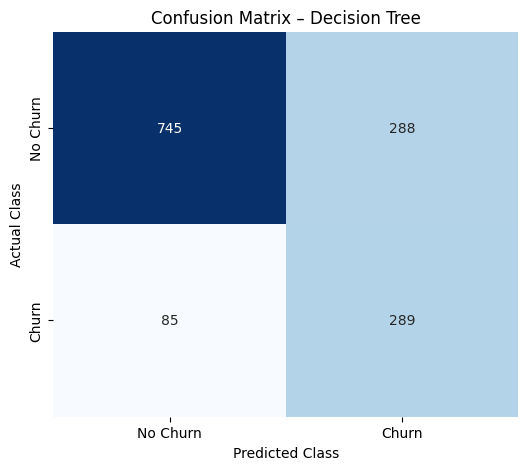

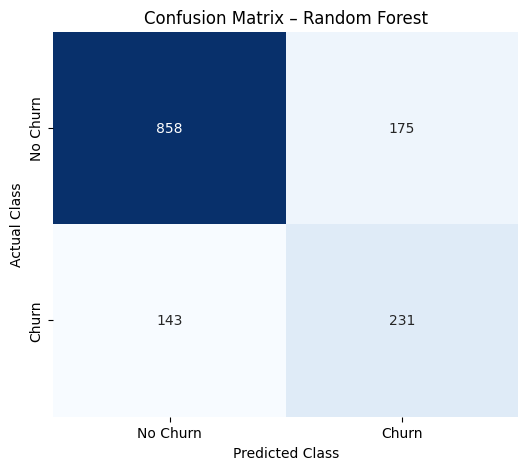

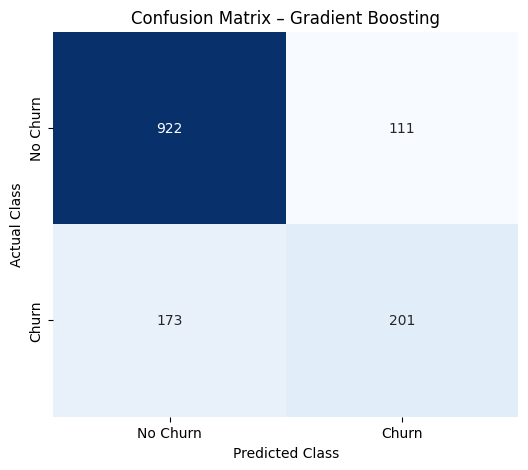

In [17]:
for model_name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=[
            "No Churn",
            "Churn"
        ],
        yticklabels=[
            "No Churn",
            "Churn"
        ]
    )

    plt.title(
        f"Confusion Matrix – {model_name}"
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    safe_name = model_name.replace(
        " ",
        "_"
    )

    plt.savefig(
        f"{image_path}/"
        f"{safe_name}_Confusion_Matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

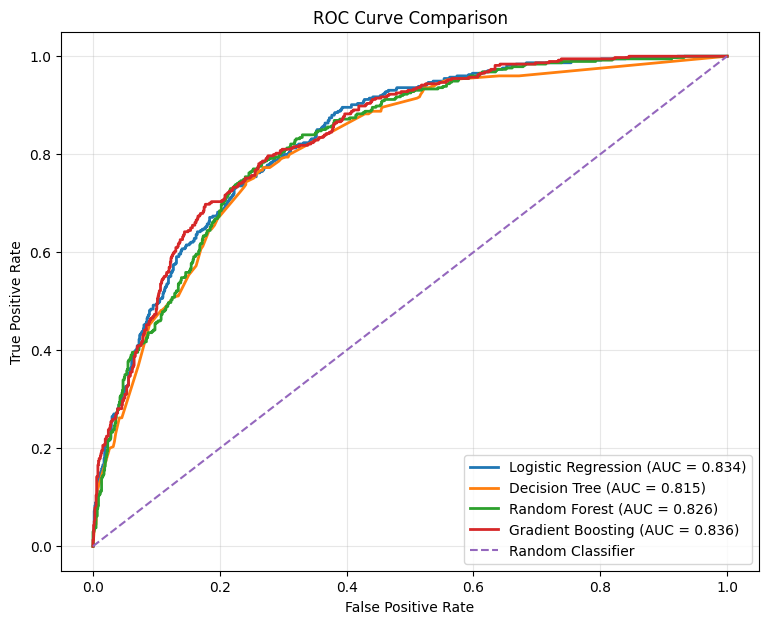

In [18]:
plt.figure(figsize=(9, 7))

roc_data = []

for model_name, model in models.items():

    y_probability = model.predict_proba(
        X_test
    )[:, 1]

    false_positive_rate, true_positive_rate, thresholds = (
        roc_curve(
            y_test,
            y_probability
        )
    )

    auc_score = roc_auc_score(
        y_test,
        y_probability
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AUC = {auc_score:.3f})"
        )
    )

    for fpr, tpr, threshold in zip(
        false_positive_rate,
        true_positive_rate,
        thresholds
    ):
        roc_data.append({
            "Model": model_name,
            "False_Positive_Rate": fpr,
            "True_Positive_Rate": tpr,
            "Threshold": threshold
        })

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    f"{image_path}/Combined_ROC_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [19]:
roc_data_df = pd.DataFrame(
    roc_data
)

roc_data_df.to_csv(
    f"{evaluation_path}/ROC_Curve_Data.csv",
    index=False
)

print("ROC curve data saved.")

ROC curve data saved.


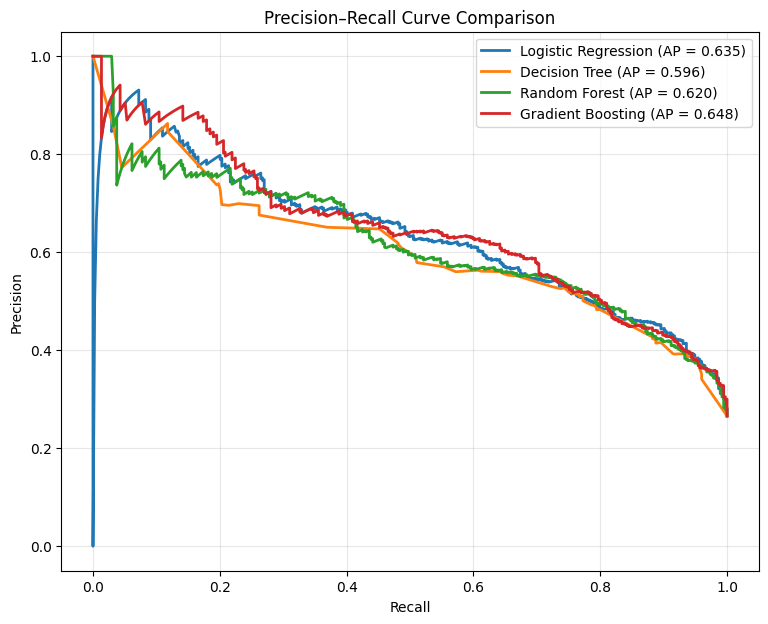

In [20]:
plt.figure(figsize=(9, 7))

precision_recall_data = []

for model_name, model in models.items():

    y_probability = model.predict_proba(
        X_test
    )[:, 1]

    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            y_test,
            y_probability
        )
    )

    average_precision = average_precision_score(
        y_test,
        y_probability
    )

    plt.plot(
        recall_values,
        precision_values,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AP = {average_precision:.3f})"
        )
    )

    threshold_values = np.append(
        thresholds,
        np.nan
    )

    for precision_value, recall_value, threshold in zip(
        precision_values,
        recall_values,
        threshold_values
    ):
        precision_recall_data.append({
            "Model": model_name,
            "Precision": precision_value,
            "Recall": recall_value,
            "Threshold": threshold
        })

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    f"{image_path}/"
    "Combined_Precision_Recall_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [21]:
precision_recall_df = pd.DataFrame(
    precision_recall_data
)

precision_recall_df.to_csv(
    f"{evaluation_path}/"
    "Precision_Recall_Curve_Data.csv",
    index=False
)

print("Precision–Recall curve data saved.")

Precision–Recall curve data saved.


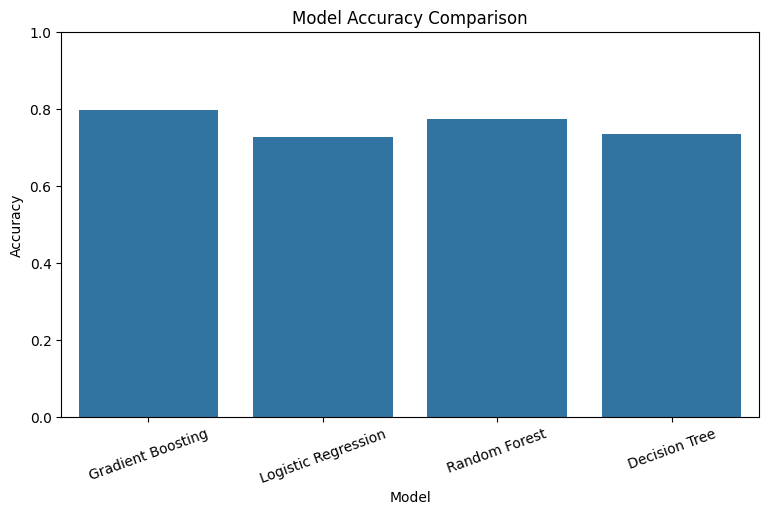

In [22]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=evaluation_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.savefig(
    f"{image_path}/"
    "Model_Accuracy_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

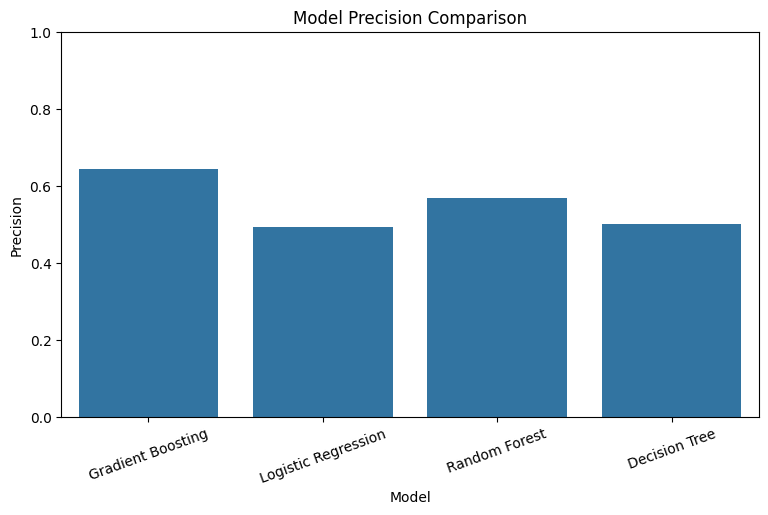

In [23]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=evaluation_df,
    x="Model",
    y="Precision"
)

plt.title("Model Precision Comparison")
plt.xlabel("Model")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.savefig(
    f"{image_path}/"
    "Model_Precision_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

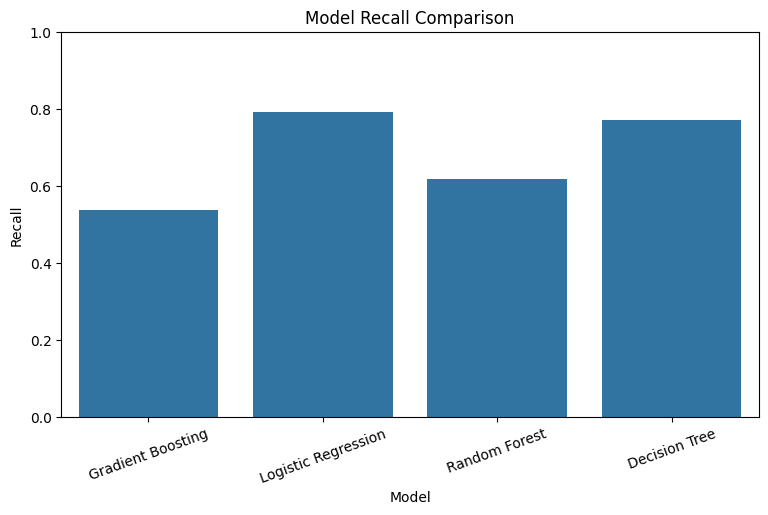

In [24]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=evaluation_df,
    x="Model",
    y="Recall"
)

plt.title("Model Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.savefig(
    f"{image_path}/"
    "Model_Recall_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

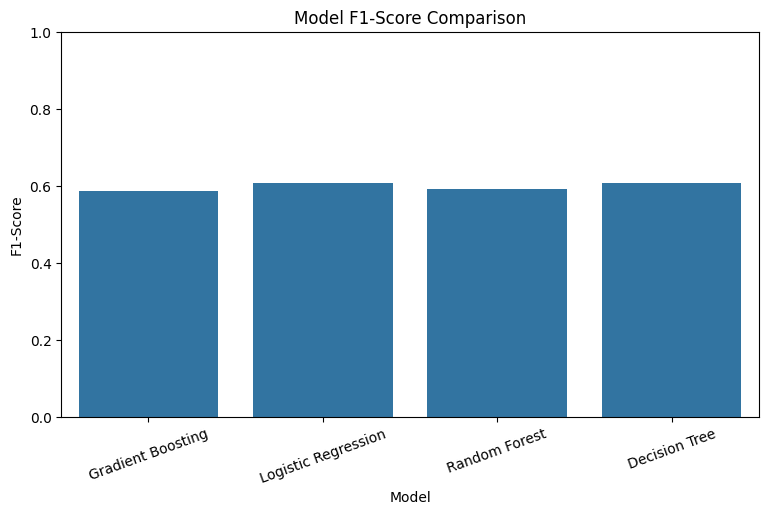

In [25]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=evaluation_df,
    x="Model",
    y="F1_Score"
)

plt.title("Model F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.savefig(
    f"{image_path}/"
    "Model_F1_Score_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

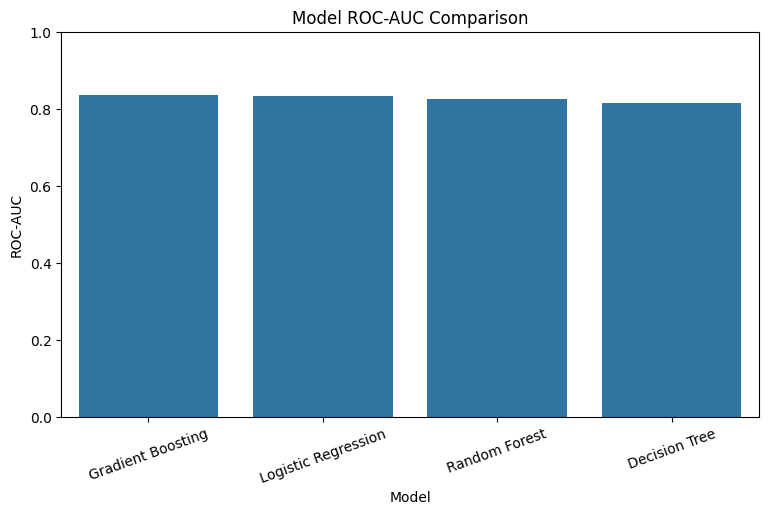

In [26]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=evaluation_df,
    x="Model",
    y="ROC_AUC"
)

plt.title("Model ROC-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.savefig(
    f"{image_path}/"
    "Model_ROC_AUC_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [27]:
comparison_long = evaluation_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score",
        "ROC_AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

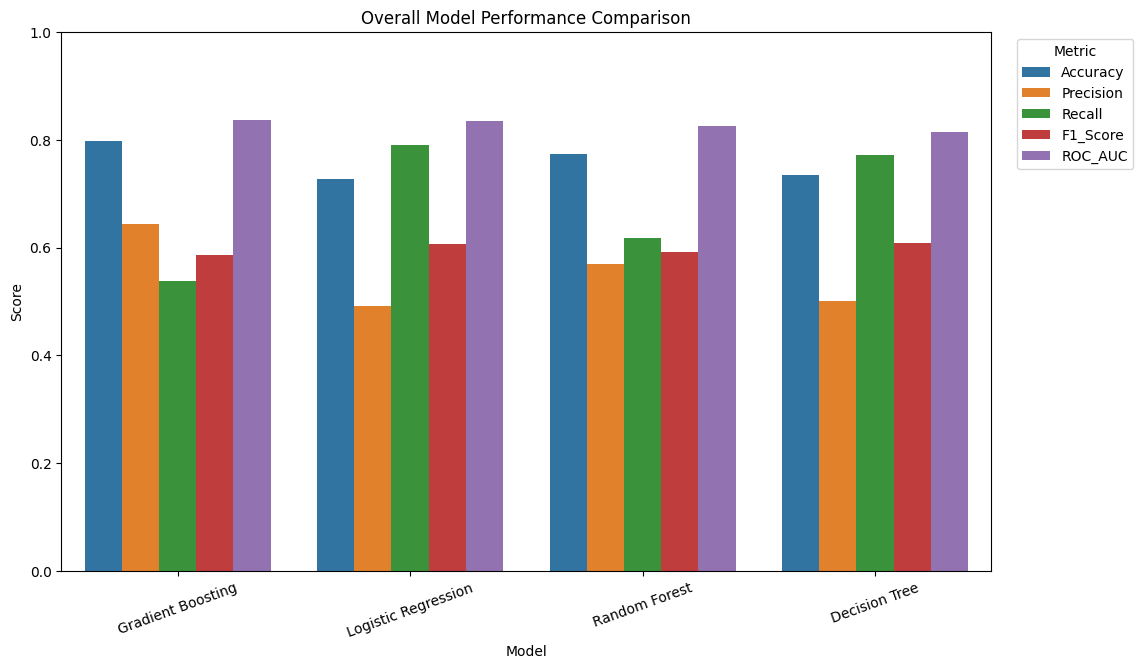

In [28]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=comparison_long,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Overall Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.savefig(
    f"{image_path}/"
    "Overall_Model_Performance_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [29]:
best_row = evaluation_df.iloc[0]

best_model_name = best_row["Model"]

best_model = models[
    best_model_name
]

print("Best Model:", best_model_name)
print(
    "ROC-AUC:",
    best_row["ROC_AUC"]
)

print(
    "F1-Score:",
    best_row["F1_Score"]
)

print(
    "Recall:",
    best_row["Recall"]
)

Best Model: Gradient Boosting
ROC-AUC: 0.8364
F1-Score: 0.586
Recall: 0.5374


In [30]:
best_model_file = (
    f"{evaluation_path}/Best_Model.pkl"
)

joblib.dump(
    best_model,
    best_model_file
)

print("Best model saved successfully:")
print(best_model_file)

Best model saved successfully:
/content/drive/MyDrive/Project_Churn Prediction/05_Model_Evaluation/Best_Model.pkl


In [31]:
best_model_summary = pd.DataFrame({
    "Selection_Criterion": [
        "Highest ROC-AUC"
    ],

    "Best_Model": [
        best_model_name
    ],

    "Accuracy": [
        best_row["Accuracy"]
    ],

    "Precision": [
        best_row["Precision"]
    ],

    "Recall": [
        best_row["Recall"]
    ],

    "F1_Score": [
        best_row["F1_Score"]
    ],

    "ROC_AUC": [
        best_row["ROC_AUC"]
    ],

    "Average_Precision": [
        best_row["Average_Precision"]
    ]
})

display(best_model_summary)

,Selection_Criterion,Best_Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Average_Precision
0,Highest ROC-AUC,Gradient Boosting,0.7982,0.6442,0.5374,0.586,0.8364,0.6483


In [32]:
best_model_summary.to_csv(
    f"{evaluation_path}/"
    "Best_Model_Summary.csv",
    index=False
)

print("Best model summary saved.")

Best model summary saved.


In [33]:
best_predictions = best_model.predict(
    X_test
)

best_probabilities = best_model.predict_proba(
    X_test
)[:, 1]

In [34]:
best_prediction_df = pd.DataFrame({
    "Actual_Churn":
        y_test.reset_index(drop=True),

    "Predicted_Churn":
        best_predictions,

    "Churn_Probability":
        best_probabilities
})

In [35]:
best_prediction_df["Risk_Category"] = pd.cut(
    best_prediction_df[
        "Churn_Probability"
    ],
    bins=[
        -0.01,
        0.30,
        0.60,
        1.00
    ],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

In [36]:
best_prediction_df.to_csv(
    f"{evaluation_path}/"
    "Best_Model_Predictions.csv",
    index=False
)

display(best_prediction_df.head())

,Actual_Churn,Predicted_Churn,Churn_Probability,Risk_Category
0,0,0,0.025838,Low Risk
1,0,1,0.620045,High Risk
2,0,0,0.024161,Low Risk
3,1,0,0.140630,Low Risk
4,0,0,0.160829,Low Risk


In [37]:
risk_summary = (
    best_prediction_df[
        "Risk_Category"
    ]
    .value_counts()
    .rename_axis(
        "Risk_Category"
    )
    .reset_index(
        name="Customer_Count"
    )
)

risk_summary["Percentage"] = (
    risk_summary[
        "Customer_Count"
    ]
    / len(best_prediction_df)
    * 100
).round(2)

display(risk_summary)

,Risk_Category,Customer_Count,Percentage
0,Low Risk,874,62.12
1,Medium Risk,322,22.89
2,High Risk,211,15.00


In [38]:
risk_summary.to_csv(
    f"{evaluation_path}/"
    "Customer_Risk_Summary.csv",
    index=False
)

In [39]:
print("Model evaluation outputs:\n")

for item in sorted(
    os.listdir(evaluation_path)
):
    print(item)

Model evaluation outputs:

All_Model_Predictions.csv
Best_Model.pkl
Best_Model_Predictions.csv
Best_Model_Summary.csv
Customer_Risk_Summary.csv
Decision_Tree_Classification_Report.csv
Gradient_Boosting_Classification_Report.csv
Images
Logistic_Regression_Classification_Report.csv
Model_Evaluation_Results.csv
Precision_Recall_Curve_Data.csv
ROC_Curve_Data.csv
Random_Forest_Classification_Report.csv


In [40]:
zip_base = (
    "/content/Model_Evaluation_Outputs"
)

shutil.make_archive(
    zip_base,
    "zip",
    evaluation_path
)

print("ZIP file created successfully:")
print(f"{zip_base}.zip")

ZIP file created successfully:
/content/Model_Evaluation_Outputs.zip


In [41]:
from google.colab import files

files.download(
    "/content/Model_Evaluation_Outputs.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>